In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import gc
import textwrap
import time

import psutil
from datetime import datetime

import anndata as an
import scanpy as sc

sc.settings.verbosity = 3

In [2]:
# Start overall timer
overall_start_time = time.time()

# File path
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/processed/sample_1_adata.h5ad"
basename = os.path.basename(fpath).replace(".h5ad", "")
print(f"Working on: {basename}")

# Read and copy data
read_start_time = time.time()
adata = sc.read_h5ad(fpath, backed='r')
df = adata.obs.copy()
read_duration = time.time() - read_start_time
print(f"\tRead + copy took: {read_duration:.2f} seconds")
print(f"\tObserved shape: {df.shape}")

# Cleanup
del adata

# Preview
df.head()

Working on: sample_1_adata


/home/jrcwycy/miniconda3/envs/scanpy/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


	Read + copy took: 43.58 seconds
	Observed shape: (1125041, 35)


,soma_joinid,dataset_id,assay,assay_ontology_term_id,cell_type,cell_type_ontology_term_id,development_stage,development_stage_ontology_term_id,disease,disease_ontology_term_id,...,raw_mean_nnz,raw_variance_nnz,n_measured_vars,basename,dataset_id_int,n_counts,n_genes,_scvi_batch,_scvi_labels,leiden
252022,18615957,2adb1f8a-a6b1-4909-8ee8-484814e2d4bf,microwell-seq,EFO:0030002,fibroblast,CL:0000057,46-year-old human stage,HsapDv:0000140,normal,PATO:0000461,...,1.240777,0.486661,26392,fibroblasts,41,639.0,515,17,95,9
257777,18675295,2adb1f8a-a6b1-4909-8ee8-484814e2d4bf,microwell-seq,EFO:0030002,fibroblast,CL:0000057,52-year-old human stage,HsapDv:0000146,normal,PATO:0000461,...,1.465909,1.322027,26392,fibroblasts,41,387.0,264,17,95,9
1231167,59490168,55003f67-c494-46f1-83fb-902745646379,10x 3' v2,EFO:0009899,fibroblast of mammary gland,CL:0002555,unknown,unknown,normal,PATO:0000461,...,1.759630,9.102627,15166,fibroblasts,361,1142.0,649,144,101,45
1269651,68707092,9f222629-9e39-47d0-b83f-e08d610c7479,10x 3' v2,EFO:0009899,alveolar type 2 fibroblast cell,CL:4028006,unknown,unknown,normal,PATO:0000461,...,3.020318,157.357447,50205,fibroblasts,168,12933.0,4282,69,45,12
657717,45885083,842c6f5d-4a94-4eef-8510-8c792d1124bc,10x 3' v3,EFO:0009922,fibroblast,CL:0000057,mature stage,HsapDv:0000204,normal,PATO:0000461,...,3.447261,134.501827,31293,fibroblasts,300,13465.0,3906,121,95,9


# Load in cell type annotations

In [3]:
fpath = "../../resources/cell_type_annotation.csv"
cdf = pd.read_csv(fpath)

type_map = dict(zip(cdf['cell_id'].values, cdf['cell_type'].values))
level_1_map = dict(zip(cdf['cell_id'].values, cdf['level_1'].values))

df['cell_type_annotation'] = df['cell_type_ontology_term_id'].map(type_map)
df['level_1_annotation'] = df['cell_type_ontology_term_id'].map(level_1_map)

df.head()

,soma_joinid,dataset_id,assay,assay_ontology_term_id,cell_type,cell_type_ontology_term_id,development_stage,development_stage_ontology_term_id,disease,disease_ontology_term_id,...,n_measured_vars,basename,dataset_id_int,n_counts,n_genes,_scvi_batch,_scvi_labels,leiden,cell_type_annotation,level_1_annotation
252022,18615957,2adb1f8a-a6b1-4909-8ee8-484814e2d4bf,microwell-seq,EFO:0030002,fibroblast,CL:0000057,46-year-old human stage,HsapDv:0000140,normal,PATO:0000461,...,26392,fibroblasts,41,639.0,515,17,95,9,fibroblast,NaN
257777,18675295,2adb1f8a-a6b1-4909-8ee8-484814e2d4bf,microwell-seq,EFO:0030002,fibroblast,CL:0000057,52-year-old human stage,HsapDv:0000146,normal,PATO:0000461,...,26392,fibroblasts,41,387.0,264,17,95,9,fibroblast,NaN
1231167,59490168,55003f67-c494-46f1-83fb-902745646379,10x 3' v2,EFO:0009899,fibroblast of mammary gland,CL:0002555,unknown,unknown,normal,PATO:0000461,...,15166,fibroblasts,361,1142.0,649,144,101,45,fibroblast of mammary gland,fibroblast
1269651,68707092,9f222629-9e39-47d0-b83f-e08d610c7479,10x 3' v2,EFO:0009899,alveolar type 2 fibroblast cell,CL:4028006,unknown,unknown,normal,PATO:0000461,...,50205,fibroblasts,168,12933.0,4282,69,45,12,alveolar type 2 fibroblast cell,fibroblast
657717,45885083,842c6f5d-4a94-4eef-8510-8c792d1124bc,10x 3' v3,EFO:0009922,fibroblast,CL:0000057,mature stage,HsapDv:0000204,normal,PATO:0000461,...,31293,fibroblasts,300,13465.0,3906,121,95,9,fibroblast,NaN


In [21]:
df['assay'].value_counts()

assay
10x 3' v3                                   409475
10x 3' v2                                   321539
10x 5' v1                                   150798
10x 5' v2                                    71544
microwell-seq                                48806
sci-RNA-seq                                  35963
ScaleBio single cell RNA sequencing          25006
10x 5' transcription profiling               22064
BD Rhapsody Targeted mRNA                    16552
10x 3' transcription profiling                7935
BD Rhapsody Whole Transcriptome Analysis      3957
Smart-seq2                                    3199
MARS-seq                                      2755
Drop-seq                                      2409
10x 3' v1                                     1572
Seq-Well                                       830
SPLiT-seq                                      227
Seq-Well S3                                    190
TruDrop                                        158
CEL-seq2                 

In [4]:
n_cells = df.shape[0]
n_cell_types = df['cell_type'].nunique()
n_tissues = df['tissue_general'].nunique()
n_datasets = df['dataset_id'].nunique()
n_assays = df['assay'].nunique()

summary = pd.DataFrame({
    "Statistic": [
        "Total Cells",
        "Unique Cell Types",
        "Unique Tissues",
        "Unique Datasets",
        "Unique Assays"
    ],
    "Count": [
        n_cells,
        n_cell_types,
        n_tissues,
        n_datasets,
        n_assays
    ]
})

print(summary.to_latex(index=False))

\begin{tabular}{lr}
\toprule
Statistic & Count \\
\midrule
Total Cells & 1125041 \\
Unique Cell Types & 188 \\
Unique Tissues & 51 \\
Unique Datasets & 270 \\
Unique Assays & 21 \\
\bottomrule
\end{tabular}



In [5]:
categorical_cols = ['dataset_id', 'assay', 'donor_id', 'sex', 'suspension_type', 'tissue', 'cell_type']

summary = df[categorical_cols].nunique().reset_index()
summary.columns = ['column', 'n_unique_values']
print(summary.to_string(index=False))

         column  n_unique_values
     dataset_id              270
          assay               21
       donor_id             3484
            sex                3
suspension_type                2
         tissue              211
      cell_type              188


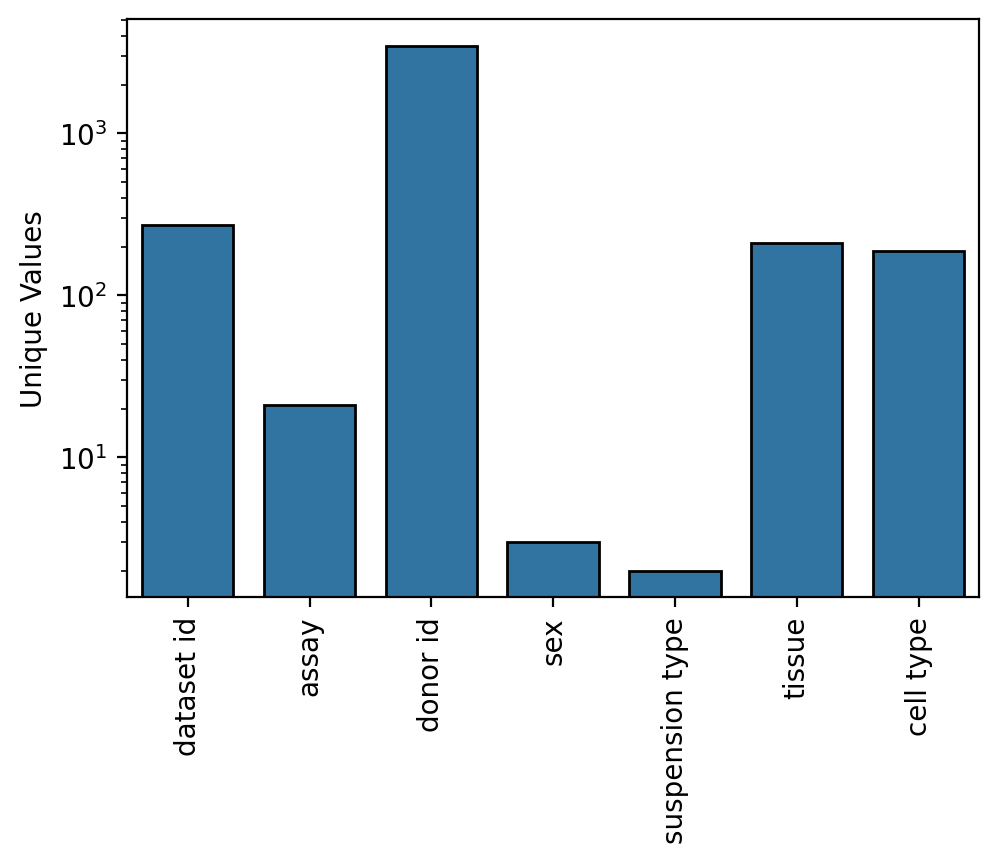

In [6]:
summary['column'] = summary['column'].apply(lambda x: x.replace("_", " "))

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5.5, 3.75
sns.barplot(
    data=summary,
    x='column',
    y='n_unique_values',
    ec='k',
    width=0.75,
)

plt.ylabel("Unique Values")
plt.xlabel("")
plt.gca().tick_params(axis='x', rotation=90)
plt.yscale('log')

/tmp/ipykernel_4122808/2192452298.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=tick_labels)


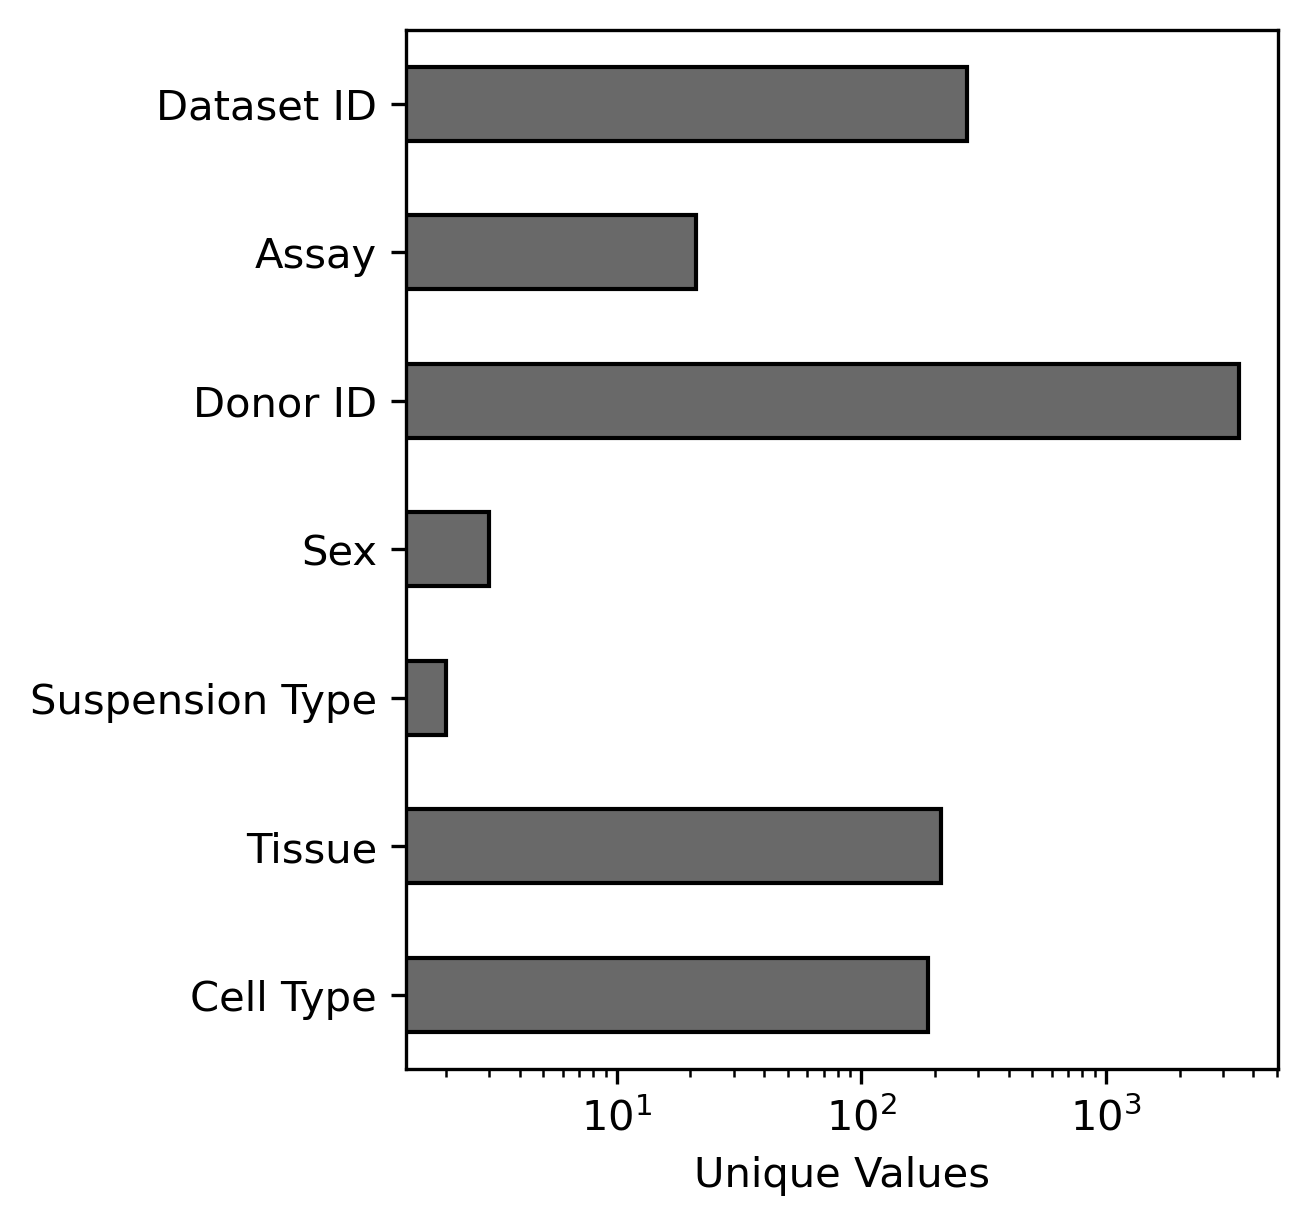

In [23]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3.75, 4.5
fig, ax = plt.subplots()

sns.barplot(
    data=summary,
    y='column',
    x='n_unique_values',
    ec='k',
    color='dimgray',
    width=0.5,
)

tick_labels = ['Dataset ID', 'Assay', 'Donor ID', 'Sex', 'Suspension Type', 'Tissue', 'Cell Type']

plt.xlabel("Unique Values")
plt.ylabel("")
ax.set_yticklabels(labels=tick_labels)
plt.xscale('log')

In [22]:
summary.head()

,column,n_unique_values
0,dataset id,270
1,assay,21
2,donor id,3484
3,sex,3
4,suspension type,2


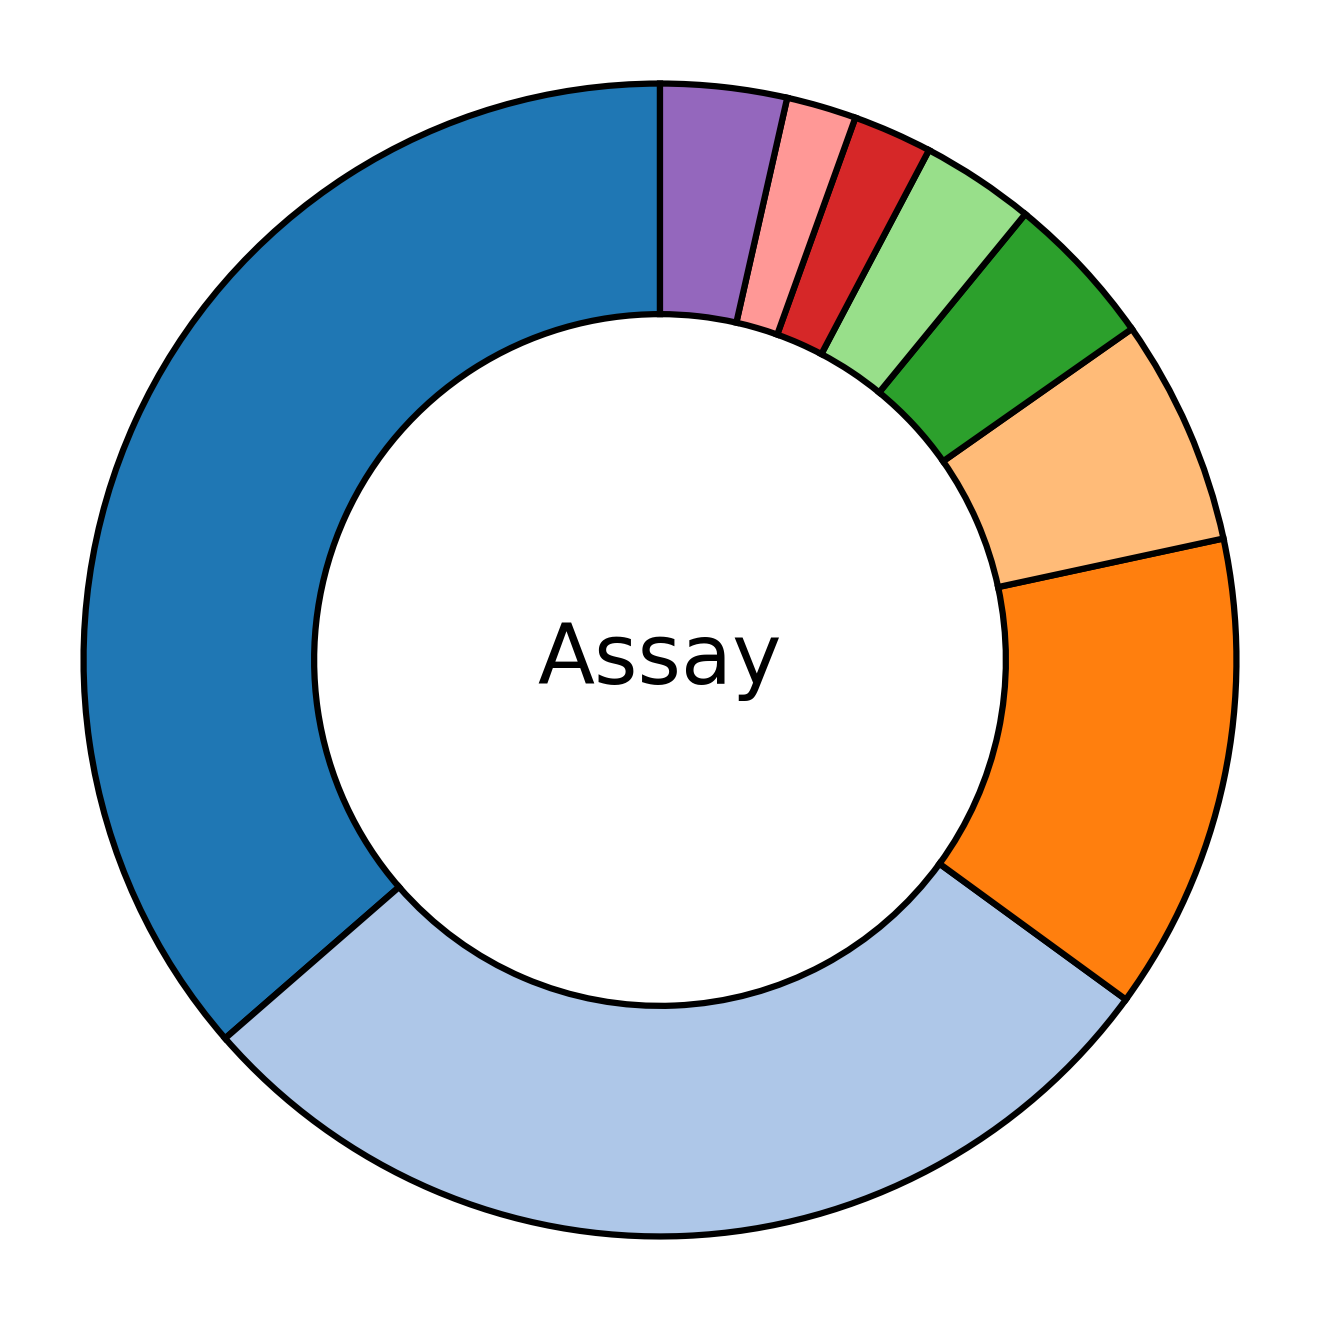

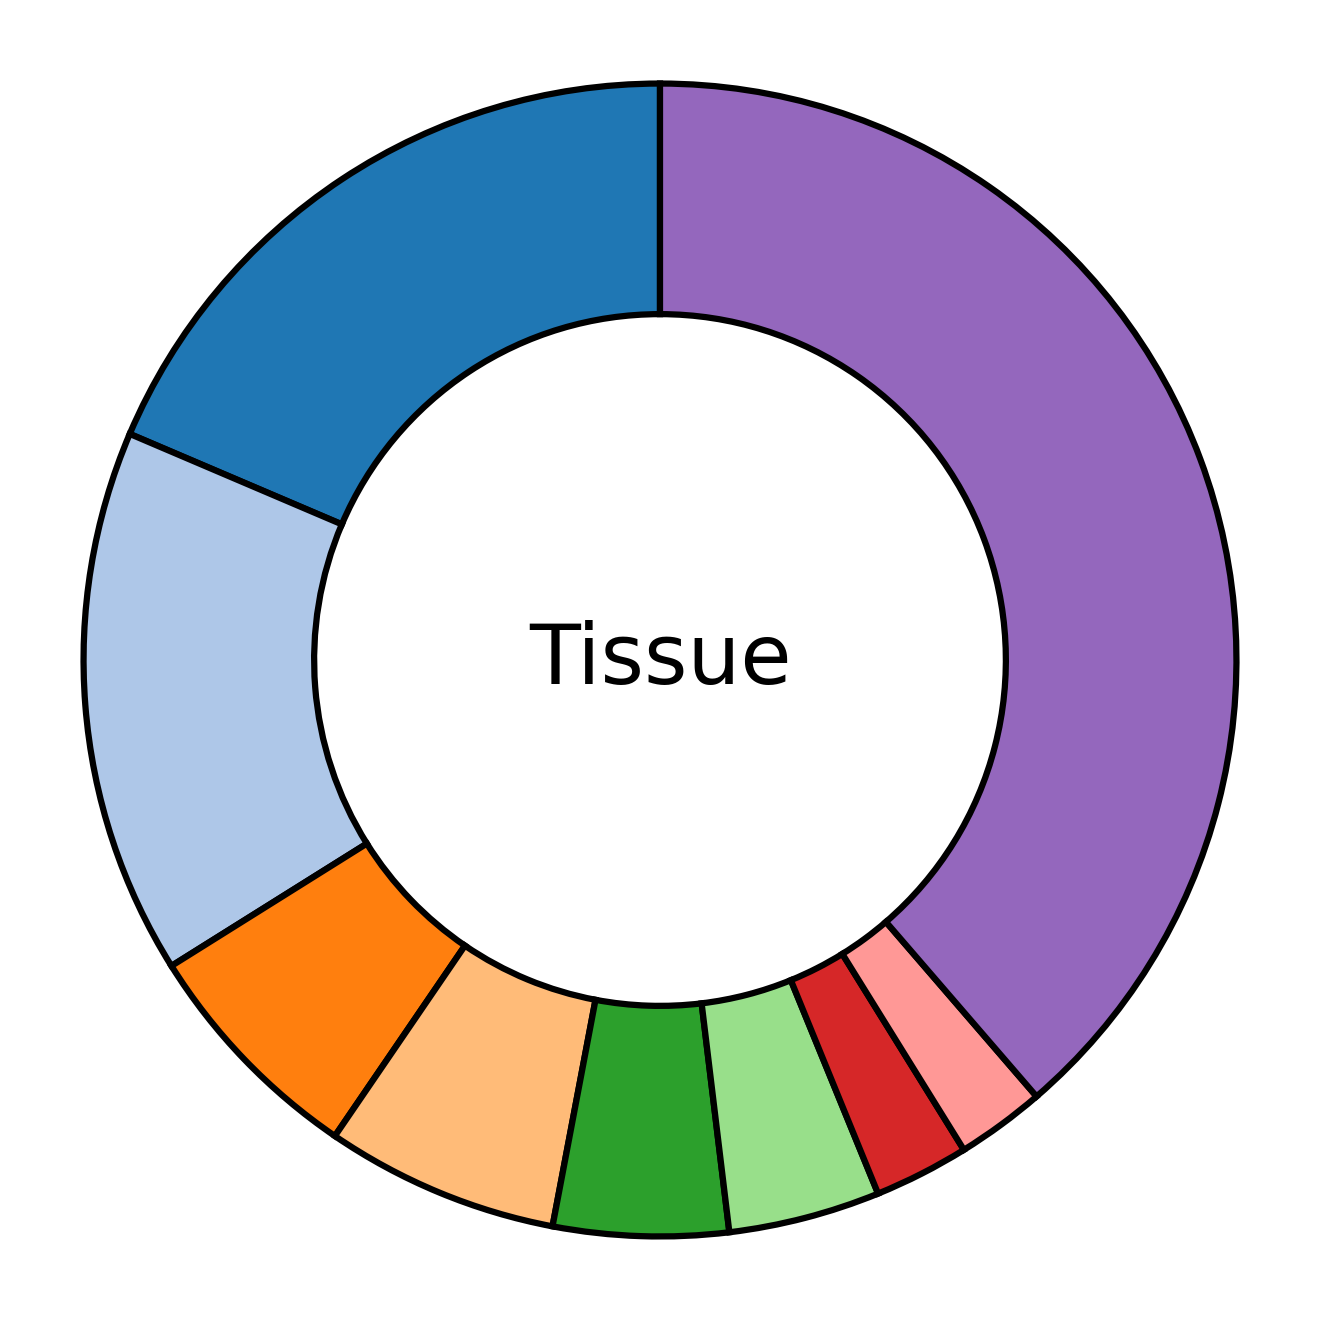

In [20]:
def plot_donut_chart(data, column, top_n=8):
    counts = data[column].value_counts()

    if len(counts) > top_n:
        top = counts[:top_n]
        other = pd.Series([counts[top_n:].sum()], index=['other'])
        counts = pd.concat([top, other])

    labels = counts.index.tolist()
    values = counts.values
    colors = sns.color_palette("tab20", n_colors=len(counts))

    fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=300)
    wedges, _ = ax.pie(
        values,
        startangle=90,
        colors=colors,
        wedgeprops=dict(width=0.4, edgecolor='black', linewidth=1.5)
    )

#     for i, wedge in enumerate(wedges):
#         angle = (wedge.theta2 + wedge.theta1) / 2.0
#         angle_rad = np.deg2rad(angle)

#         # Radial position: just beyond the wedge
#         outer_radius = 1.25
#         x = outer_radius * np.cos(angle_rad)
#         y = outer_radius * np.sin(angle_rad)

#         # Determine alignment and rotation for outward-facing text
#         rotation = np.rad2deg(angle_rad)
#         alignment = 'left' if -90 <= rotation <= 90 else 'right'

#         if alignment == 'right':
#             rotation += 180  # flip text to keep upright

#         # Wrap label to multiple lines if needed
#         wrapped_label = "\n".join(textwrap.wrap(labels[i], width=20))
#         label_text = f"{wrapped_label}"

#         ax.annotate(
#             label_text,
#             xy=(np.cos(angle_rad), np.sin(angle_rad)),
#             xytext=(x, y),
#             ha=alignment,
#             va='center',
#             fontsize=9,
#             weight='bold',
#             rotation=rotation,
#             rotation_mode='anchor',
#             arrowprops=dict(arrowstyle='-', lw=0.5, color='gray'),
#             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.9)
#         )

    # Central title inside the donut
    ax.text(
        0, 0,
        column.replace("_", "\n").title(),
        ha='center',
        va='center',
        fontsize=20,
        # weight='bold'
    )

    ax.axis('equal')
    plt.tight_layout()
    plt.show()


# Example use
categorical_cols = ['assay', 'tissue']
for col in categorical_cols:
    plot_donut_chart(df, col)

In [32]:
# def plot_donut_chart(data, column, top_n=8):
#     counts = data[column].value_counts()

#     if len(counts) > top_n:
#         top = counts[:top_n]
#         other = pd.Series([counts[top_n:].sum()], index=['other'])
#         counts = pd.concat([top, other])

#     labels = counts.index.tolist()
#     values = counts.values
#     colors = sns.color_palette("tab20", n_colors=len(counts))

#     fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
#     wedges, _ = ax.pie(
#         values,
#         startangle=90,
#         colors=colors,
#         wedgeprops=dict(width=0.35, edgecolor='black')
#     )

#     for i, wedge in enumerate(wedges):
#         angle = (wedge.theta2 + wedge.theta1) / 2.0
#         angle_rad = np.deg2rad(angle)

#         # Radial position: just beyond the wedge
#         outer_radius = 1.2
#         x = outer_radius * np.cos(angle_rad)
#         y = outer_radius * np.sin(angle_rad)

#         # Determine alignment and rotation for outward-facing text
#         rotation = np.rad2deg(angle_rad)
#         alignment = 'left' if -90 <= rotation <= 90 else 'right'

#         if alignment == 'right':
#             rotation += 180  # flip text to keep upright

#         # Use annotate for fine control
#         ax.annotate(
#             f"{labels[i]} ({values[i]:,})",
#             xy=(np.cos(angle_rad), np.sin(angle_rad)),
#             xytext=(x, y),
#             ha=alignment,
#             va='center',
#             fontsize=10,
#             weight='bold',
#             rotation=rotation,
#             rotation_mode='anchor',
#             arrowprops=dict(arrowstyle='-', lw=0.5, color='gray'),
#             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.9)
#         )
           
#     ax.set_title(f"{column.replace('_', ' ').title()}", fontsize=18, pad=20, weight='bold',)
#     ax.axis('equal')
#     plt.tight_layout()
#     plt.show()

# # Example use
# categorical_cols = ['assay', 'tissue']
# for col in categorical_cols:
#     plot_donut_chart(df, col)

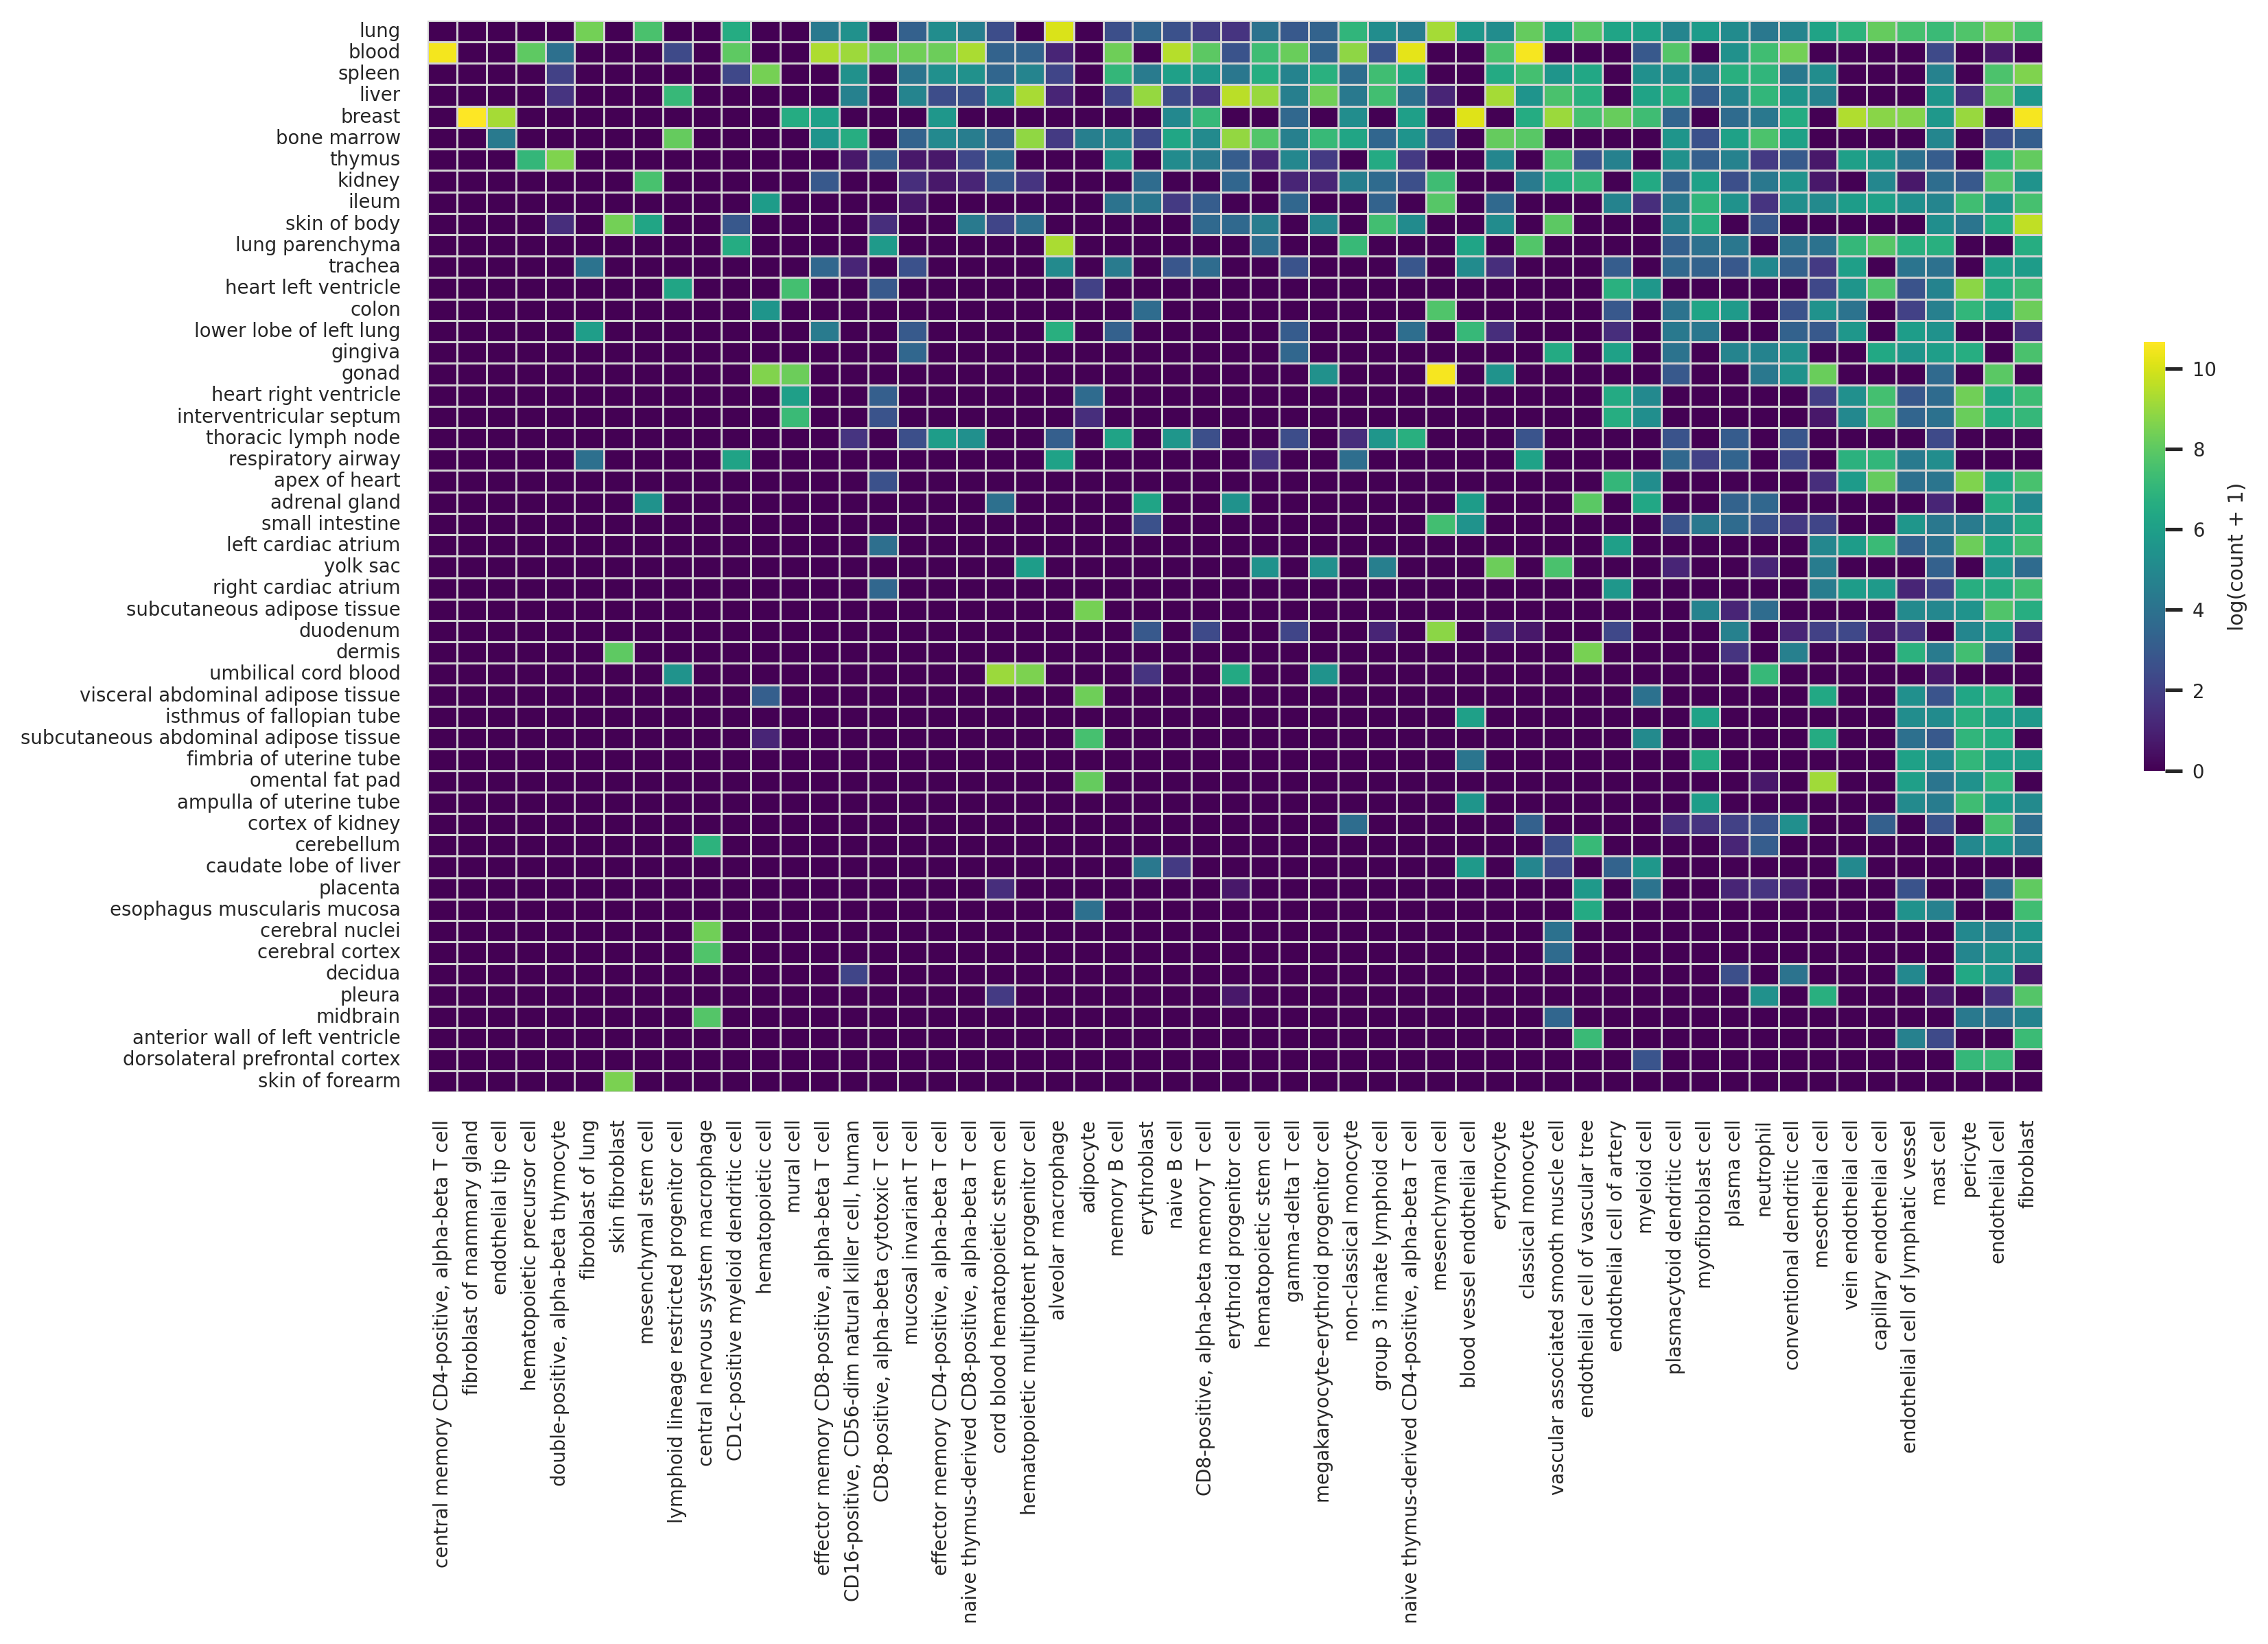

In [17]:
# Step 1: Crosstab (raw counts)
X_raw = pd.crosstab(df['tissue'], df['cell_type'])

# Step 2: Compute row and column totals
row_totals = X_raw.sum(axis=1).sort_values(ascending=False)
col_totals = X_raw.sum(axis=0).sort_values(ascending=False)

# Step 3: Keep rows/columns up to 80% cumulative sum
def top_by_cumsum(series, fraction=0.8):
    cumsum = series.cumsum()
    cutoff = series.sum() * fraction
    return series[cumsum <= cutoff].index

top_rows = top_by_cumsum(row_totals, 0.9)
top_cols = top_by_cumsum(col_totals, 0.9)

# Step 4: Filter and log-transform
X_filtered = X_raw.loc[top_rows, top_cols]
X = np.log1p(X_filtered)

# Sort rows and columns by total values
X = X.loc[X.sum(axis=1).sort_values(ascending=False).index]
X = X[X.sum(axis=0).sort_values().index]  # low to high (left to right)

# Step 5: Plot
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 8)
sns.set(font_scale=0.6)

sns.heatmap(
    X,
    cmap='viridis',
    linewidths=0.25,
    linecolor='lightgray',
    cbar_kws={"label": "log(count + 1)", "shrink": 0.4},
)

plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [ ]:
break

In [ ]:
df.columns

In [ ]:
# Compute value counts
value_counts = df['basename'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.tab20c(np.linspace(0, 1, len(value_counts_grouped)))


# Pie chart without labels
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
# Compute value counts
value_counts = df['level_1_annotation'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.tab20c(np.linspace(0, 1, len(value_counts_grouped)))

size = 10

# Pie chart without labels
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Summary of HSC Types

In [ ]:
query = 'hsc and progenitors'

print(f"{query}")
pdf = df[df['basename'] == query]
print(f"\tn cells {pdf.shape[0]}")
print(f"\tn cell types {pdf['cell_type_annotation'].nunique()}")
print(f"\tn cell types {pdf['level_1_annotation'].nunique()}")

In [ ]:
# Compute value counts
value_counts = pdf['level_1_annotation'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.Spectral(np.linspace(0, 1, len(value_counts_grouped)))

size = 8
# Pie chart without labels
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_title('Cell Categories')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Compute value counts
value_counts = pdf['cell_type_annotation'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.Spectral(np.linspace(0, 1, len(value_counts_grouped)))

size = 11
# Pie chart without labels
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_title('Cell Types')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
print(value_counts_grouped.reset_index().to_latex(index=False))

# Tissues and Assays

In [ ]:
# Compute value counts
value_counts = df['assay'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.turbo(np.linspace(0, 1, len(value_counts_grouped)))

size = 11
# Pie chart without labels
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Compute value counts
value_counts = df['tissue_general'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.gnuplot(np.linspace(0, 1, len(value_counts_grouped)))

size = 11
# Pie chart without labels
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
df.columns

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sns.boxplot(
    data=df,
    x='basename',
    y='nnz',
    hue='basename',
    palette='tab10',
    width=0.5,
    showfliers=False,
    linecolor='k',
)

plt.gca().tick_params(axis='x', rotation=90)
plt.ylabel("n genes")
plt.xlabel("")

In [ ]:
break

In [ ]:
# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 15, 4

# sns.boxplot(
#     data=df,
#     x='basename',
#     hue='cell_type',
#     y='nnz',
#     showfliers=False,
# )
# # 
# # plt.gca().tick_params(axis='x', rotation=90)÷